# Analysis of LCN and PTPS pre and post 10 day intervention. 
Student ID: 23451794514

**Designing and Evaluating a New Nature Connection Intervention for Londoners Using the 5 pathways Framework: A Human-Centred Design, tested in a Mixed Methods Quasi-Experimen** 

## How data was collected
This study employed an embedded quasi-experimental design using a waitlist control to understand if 10 short nature connection tasks delivered over 10 days via whatsapp could enhance love and care for nature. Further to this, I wanted to understand if perceived time poverty was the predictor for intervention outcomes based on data gathered for RQ1.

**MEASURES:**
To measure these changes, the following validates survey scales were used:


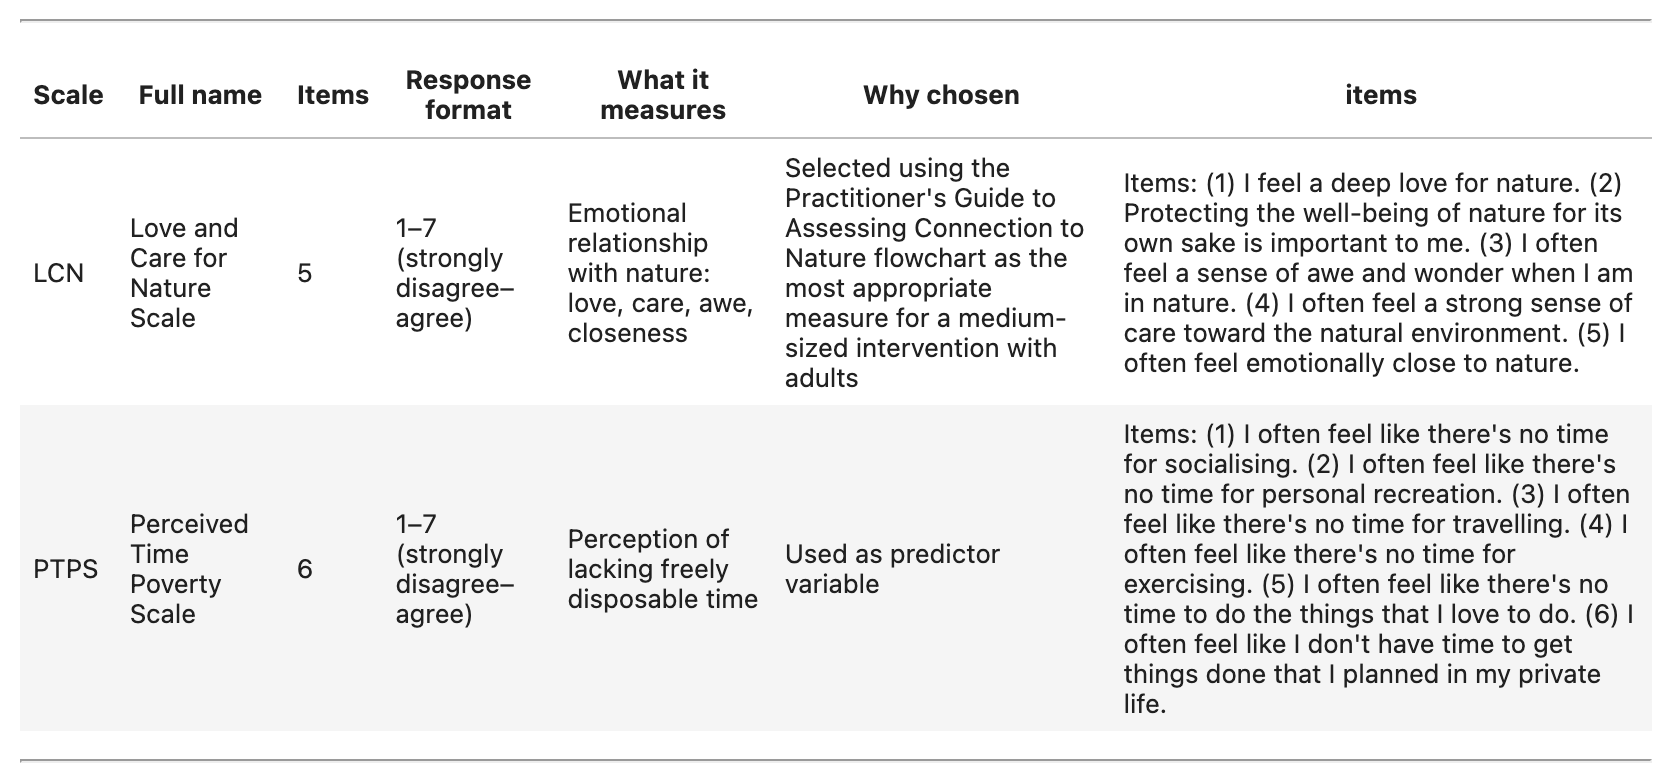

In [1]:
from IPython.display import Image
Image('table_of_measures.png')

**THE DATA COLLECTION STRUCTURE:**

Quantitative data was collected at two timepoints across the study. At sign-up, all participants completed baseline LCN and PTPS measures, which were used to establish matched pairs before group allocation. On Day 10, both groups completed a post-intervention LCN survey. Group B then began their tasks, but no further quantitative measures were collected.

---

This codebook addresses the following hypotheses:

### The Hypotheses

**RQ2:** “Does completing an urban bird connection toolkit over 10 days produce measurable changes in outcomes compared to a waitlist control?”

> **H1:**
After the 10 days, users who use the toolkit show significantly greater increases in nature connectedness than the waitlist control




> **H2:** Perceived time poverty does not predict outcomes in this sample:
> 
> &nbsp;&nbsp;&nbsp;&nbsp;**H2.1** PTPS scores do not predict task engagement across the intervention period.
> 
> &nbsp;&nbsp;&nbsp;&nbsp;**H2.2** PTPS scores do not predict changes in LCN scores following the intervention.es.

### Preprocessing data plan

1. Import libraries and data
2. Check for Identifiers Immediately
3. Filter dataframe to relevant columns only
4. Take out incomplete and withdrawn participants from the dataframe
5. Check for NaN
6. Calculate individual score changes

# Pre-processing Data

> 1. Import Libraries and data

In [2]:
# I start by importing Pandas
import pandas as pd
!pip install openpyxl #I need this to open the .xlsx file 


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
# I am reading the master spreadsheet with final data into the notebook, specifically sheet 1 
all_data_ever = pd.read_excel('ANONYMISED_dataset.xlsx', sheet_name='Sheet1')

In [4]:
# Now I am checking which columns are in this spreadsheet
print(all_data_ever.columns.tolist())

['ID', 'Pre_LCN_1', 'Post_LCN_1', 'Pre_LCN_2', 'Post_LCN_2', 'Pre_LCN_3', 'Post_LCN_3', 'Pre_LCN_4', 'Post_LCN_4', 'Pre_LCN_5', 'Post_LCN_5', 'PTPS_1', 'PTPS_2', 'PTPS_3', 'PTPS_4', 'PTPS_5', 'PTPS_6', 'blackbird_senses', 'robin_emotions', 'blue_tit_emotions', 'merlin_sense', 'magpie_meaning', '3_things_beauty', 'perspective_compassion', 'photo_beauty', 'greenfinch_compassion', 'local_meaning', 'Task_engagement', 'Pre_LCN_score', 'Post_LCN_score', 'PTPS_Score', 'matched_pair', 'Group', 'Status of participation ', "Are there any tasks which provided you with a tool/mindset/practice that you think you may continue to use? Or any you definitely won't use? What are they and why", 'Did you notice any feelings come up during tasks/after tasks/ when the study finished? Which feelings and why', 'Do you think your relationship to/with birds has changed at all? Any thoughts as to why?', 'Did the tasks feel accessible and easy to engage with personally, or were there things that got in the way li

> 2. Check for Identifiers Immediately

In [5]:
# Checking for identifiers
all_data_ever.head(5)

,ID,Pre_LCN_1,Post_LCN_1,Pre_LCN_2,Post_LCN_2,Pre_LCN_3,Post_LCN_3,Pre_LCN_4,Post_LCN_4,Pre_LCN_5,...,Pre_LCN_score,Post_LCN_score,PTPS_Score,matched_pair,Group,Status of participation,Are there any tasks which provided you with a tool/mindset/practice that you think you may continue to use? Or any you definitely won't use? What are they and why,Did you notice any feelings come up during tasks/after tasks/ when the study finished? Which feelings and why,Do you think your relationship to/with birds has changed at all? Any thoughts as to why?,"Did the tasks feel accessible and easy to engage with personally, or were there things that got in the way like time, mobility, location, or anything else?"
0,P26,3,5.0,5,5.0,5,4.0,5,5.0,3,...,4.2,4.6,2.67,0,A,complete,I had never previously paid attention to the b...,I found myself feeling more grateful for the n...,Yes - I honestly never really thought about bi...,Tasks feel accessible and easy to engage with…
1,P6,5,4.0,7,6.0,3,4.0,5,5.0,3,...,4.6,4.6,4.33,1,A,complete,"I dont think so, birds may be nice but they co...","Anxiety, I’ve grown to dislike talking about b...","I dislike birds, as I attach a newfound negati...",Missing one day of tasks and having another co...
2,P61,5,NaN,5,NaN,5,NaN,4,NaN,4,...,4.6,0.0,4.50,2,A,Withdrawn - delete data,NaN,NaN,NaN,NaN
3,P7,5,6.0,5,5.0,5,7.0,5,6.0,4,...,4.8,6.0,5.67,3,A,complete,It was nice to go out looking for birds. It ma...,NaN,I think I will be a bit more friendly with tho...,Tasks feel accessible and easy to engage with…
4,P2,5,5.0,5,5.0,5,5.0,5,5.0,5,...,5.0,5.0,5.33,4,A,complete,NaN,I thought the tasks were sweet but overall the...,No - I have a phobia of feathers and thus birds,I think I found how abstract and emotive a lot...


> 3. Filter dataframe to relevant columns only

In [6]:
# Now I am getting rid of the qual columns that are for thematic analysis in Nvivo, etc that wont be needed for the codebook. 
print (all_data_ever.columns.tolist())

['ID', 'Pre_LCN_1', 'Post_LCN_1', 'Pre_LCN_2', 'Post_LCN_2', 'Pre_LCN_3', 'Post_LCN_3', 'Pre_LCN_4', 'Post_LCN_4', 'Pre_LCN_5', 'Post_LCN_5', 'PTPS_1', 'PTPS_2', 'PTPS_3', 'PTPS_4', 'PTPS_5', 'PTPS_6', 'blackbird_senses', 'robin_emotions', 'blue_tit_emotions', 'merlin_sense', 'magpie_meaning', '3_things_beauty', 'perspective_compassion', 'photo_beauty', 'greenfinch_compassion', 'local_meaning', 'Task_engagement', 'Pre_LCN_score', 'Post_LCN_score', 'PTPS_Score', 'matched_pair', 'Group', 'Status of participation ', "Are there any tasks which provided you with a tool/mindset/practice that you think you may continue to use? Or any you definitely won't use? What are they and why", 'Did you notice any feelings come up during tasks/after tasks/ when the study finished? Which feelings and why', 'Do you think your relationship to/with birds has changed at all? Any thoughts as to why?', 'Did the tasks feel accessible and easy to engage with personally, or were there things that got in the way li

In [7]:
# Theres way too many columns so I need to drop any qualitative data columns
all_data_ever = all_data_ever.drop(columns=
                                   ['blackbird_senses',
                                    'robin_emotions',
                                    'blue_tit_emotions',
                                    'merlin_sense',
                                    'magpie_meaning',
                                    '3_things_beauty',
                                    'perspective_compassion',
                                    'photo_beauty',
                                    'greenfinch_compassion',
                                    'local_meaning',
                                    "Are there any tasks which provided you with a tool/mindset/practice that you think you may continue to use? Or any you definitely won't use? What are they and why",
                                    'Did you notice any feelings come up during tasks/after tasks/ when the study finished? Which feelings and why',
                                    'Do you think your relationship to/with birds has changed at all? Any thoughts as to why?',
                                    'Did the tasks feel accessible and easy to engage with personally, or were there things that got in the way like time, mobility, location, or anything else?',
                                   ]
                                  )
all_data_ever

,ID,Pre_LCN_1,Post_LCN_1,Pre_LCN_2,Post_LCN_2,Pre_LCN_3,Post_LCN_3,Pre_LCN_4,Post_LCN_4,Pre_LCN_5,...,PTPS_4,PTPS_5,PTPS_6,Task_engagement,Pre_LCN_score,Post_LCN_score,PTPS_Score,matched_pair,Group,Status of participation
0,P26,3,5.0,5,5.0,5,4.0,5,5.0,3,...,2.0,2.0,3.0,10,4.2,4.6,2.67,0,A,complete
1,P6,5,4.0,7,6.0,3,4.0,5,5.0,3,...,4.0,4.0,5.0,1,4.6,4.6,4.33,1,A,complete
2,P61,5,NaN,5,NaN,5,NaN,4,NaN,4,...,5.0,4.0,3.0,1,4.6,0.0,4.50,2,A,Withdrawn - delete data
3,P7,5,6.0,5,5.0,5,7.0,5,6.0,4,...,5.0,7.0,4.0,10,4.8,6.0,5.67,3,A,complete
4,P2,5,5.0,5,5.0,5,5.0,5,5.0,5,...,6.0,6.0,5.0,2,5.0,5.0,5.33,4,A,complete
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,P27,7,NaN,7,NaN,7,NaN,7,NaN,7,...,1.0,1.0,1.0,0,7.0,0.0,1.00,30,B,No post measures completed
66,P20,7,7.0,7,7.0,7,7.0,7,7.0,7,...,4.0,7.0,6.0,8,7.0,6.6,5.50,31,B,complete
67,P73,7,7.0,7,7.0,7,7.0,7,7.0,7,...,6.0,6.0,7.0,0,7.0,7.0,5.50,32,B,complete
68,P68,7,7.0,7,7.0,7,7.0,7,7.0,7,...,6.0,6.0,6.0,0,7.0,7.0,5.33,33,B,complete


> 4. Take out incomplete and withdrawn participants from the dataframe

In [8]:
# I need to get rid of any participants rows who withdrew their data. 
all_data_ever['Status of participation '].unique()

array(['complete', 'Withdrawn - delete data',
       'No post measures completed', 'Withdrawn - keep data',
       'Withdrawn by researcher as did not complete tasks',
       'PTPS measures missing ', 'No post measures completed '],
      dtype=object)

In [9]:
# Based on these I need to delete all except for 'complete'
# 'Withdrawn - keep data' refers to qualitative data so was not kept
all_data_ever = all_data_ever[all_data_ever['Status of participation '].isin(['complete'])] 
all_data_ever.head()

,ID,Pre_LCN_1,Post_LCN_1,Pre_LCN_2,Post_LCN_2,Pre_LCN_3,Post_LCN_3,Pre_LCN_4,Post_LCN_4,Pre_LCN_5,...,PTPS_4,PTPS_5,PTPS_6,Task_engagement,Pre_LCN_score,Post_LCN_score,PTPS_Score,matched_pair,Group,Status of participation
0,P26,3,5.0,5,5.0,5,4.0,5,5.0,3,...,2.0,2.0,3.0,10,4.2,4.6,2.67,0,A,complete
1,P6,5,4.0,7,6.0,3,4.0,5,5.0,3,...,4.0,4.0,5.0,1,4.6,4.6,4.33,1,A,complete
3,P7,5,6.0,5,5.0,5,7.0,5,6.0,4,...,5.0,7.0,4.0,10,4.8,6.0,5.67,3,A,complete
4,P2,5,5.0,5,5.0,5,5.0,5,5.0,5,...,6.0,6.0,5.0,2,5.0,5.0,5.33,4,A,complete
5,P21,5,7.0,6,6.0,5,7.0,6,7.0,4,...,4.0,4.0,5.0,5,5.2,6.4,4.50,5,A,complete


In [10]:
# checking that only complete rows are left.
all_data_ever['Status of participation '].unique()

array(['complete'], dtype=object)

In [11]:
all_data_ever.groupby('Group').size() 

Group
A    28
B    31
dtype: int64

Once all withdrawn/missing data had been accounted for, we are left with 28 - 31 participants. = total of 59 participants

> 5.Check for NaN

In [12]:
#checking for NaN values across the dataframe.
all_data_ever[all_data_ever.isnull().any(axis=1)] 
# isnull() flags every NaN cell and .any(axis=1) checks if any NaN exists across each row

,ID,Pre_LCN_1,Post_LCN_1,Pre_LCN_2,Post_LCN_2,Pre_LCN_3,Post_LCN_3,Pre_LCN_4,Post_LCN_4,Pre_LCN_5,...,PTPS_4,PTPS_5,PTPS_6,Task_engagement,Pre_LCN_score,Post_LCN_score,PTPS_Score,matched_pair,Group,Status of participation


> 6. Calculate individual score changes

In [13]:
# I want to add a column for each individual persons change for LCN
all_data_ever = all_data_ever.copy()
all_data_ever['LCN_change'] = all_data_ever['Post_LCN_score'] - all_data_ever['Pre_LCN_score'] #making the new column
all_data_ever.head()

,ID,Pre_LCN_1,Post_LCN_1,Pre_LCN_2,Post_LCN_2,Pre_LCN_3,Post_LCN_3,Pre_LCN_4,Post_LCN_4,Pre_LCN_5,...,PTPS_5,PTPS_6,Task_engagement,Pre_LCN_score,Post_LCN_score,PTPS_Score,matched_pair,Group,Status of participation,LCN_change
0,P26,3,5.0,5,5.0,5,4.0,5,5.0,3,...,2.0,3.0,10,4.2,4.6,2.67,0,A,complete,0.4
1,P6,5,4.0,7,6.0,3,4.0,5,5.0,3,...,4.0,5.0,1,4.6,4.6,4.33,1,A,complete,0.0
3,P7,5,6.0,5,5.0,5,7.0,5,6.0,4,...,7.0,4.0,10,4.8,6.0,5.67,3,A,complete,1.2
4,P2,5,5.0,5,5.0,5,5.0,5,5.0,5,...,6.0,5.0,2,5.0,5.0,5.33,4,A,complete,0.0
5,P21,5,7.0,6,6.0,5,7.0,6,7.0,4,...,4.0,5.0,5,5.2,6.4,4.50,5,A,complete,1.2


## Processing data plan
Processing data for this codebook includes the following:

- Shapiro-Wilk tests of distribution
- Mann-Whitney U tests
- Rank-biserial correlations
- Cohens D tests
- The Probability of Superiority
- Sensitivity checks
- OLS regressions
- Visualisations

In [14]:
# Importing all necessary libraries!
from scipy.stats import mannwhitneyu
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import wilcoxon

# H1: Love and Care for Nature scale
> **H1 (primary):**
After the 10 days, users who use the toolkit show significantly greater increases in nature connectedness than the waitlist control

In [15]:
#These are the columns Im keeping in a new dataframe for LCN calculations.
#I'm removing all individual item data columns since scores and changes have already been calculated
LCN_dataframe = all_data_ever[['ID', 'Task_engagement', 'Pre_LCN_score', 'Post_LCN_score', 'matched_pair', 'Group', 'Status of participation ', 'LCN_change']]

In [16]:
LCN_dataframe.head()

,ID,Task_engagement,Pre_LCN_score,Post_LCN_score,matched_pair,Group,Status of participation,LCN_change
0,P26,10,4.2,4.6,0,A,complete,0.4
1,P6,1,4.6,4.6,1,A,complete,0.0
3,P7,10,4.8,6.0,3,A,complete,1.2
4,P2,2,5.0,5.0,4,A,complete,0.0
5,P21,5,5.2,6.4,5,A,complete,1.2


In [17]:
#checking that my baseline measures are still even between groups even after the 8 dropouts!
print(LCN_dataframe.groupby('Group')['Pre_LCN_score'].describe())

       count      mean       std  min   25%  50%  75%  max
Group                                                     
A       28.0  6.057143  0.801586  4.2  5.55  6.2  6.8  7.0
B       31.0  6.012903  0.813118  4.4  5.40  6.2  6.6  7.0


That's very well balanced. The means of pre_LCN_scores are virtually identical (A: 6.06, B: 6.01), standard deviations are almost the same too which shows that the groups are well balanced at baseline for LCN despite the dropouts. Matched pair groups are necessary for this kind of analysis because if the groups start at different levels, we can't confidently attribute any difference at post-test to the intervention. Before running any statistical tests, we also check for outliers 
in the LCN_change scores that could influence our results

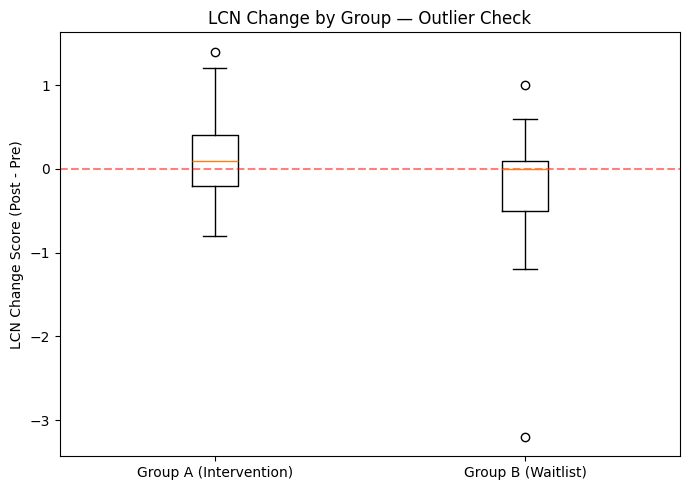

In [18]:
# checking for any outliers in our data by visualising!
fig, ax = plt.subplots(figsize=(7, 5)) #empty plot
# A boxplot takes a list of two arrays, one for each group's LCN_change scores
# each array is made by filtering the dataframe to that group only
ax.boxplot([
    LCN_dataframe[LCN_dataframe['Group'] == 'A']['LCN_change'], # Group A's change scores
    LCN_dataframe[LCN_dataframe['Group'] == 'B']['LCN_change'] # group B's change scores
], tick_labels=['Group A (Intervention)', 'Group B (Waitlist)'])
# red dotted line at 0 - any box above this line means that group increased on average
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('LCN Change Score (Post - Pre)')
ax.set_title('LCN Change by Group — Outlier Check')

plt.tight_layout()
plt.show()

The boxplot reveals one notable outlier in Group B at -3.2 and mild outliers in both groups at the upper end (Group A: 1.4, Group B: 1.0). The -3.2 is the most extreme value and worth monitoring. How we handle these outliers will depend on which statistical test we run next. Parametric tests (e.g. t-test) are sensitive to outliers and may require removal or transformation, whereas non-parametric tests (e.g. Mann-Whitney) are rank-based and therefore robust to them.

Therefore, we need to run a Shapiro-Wilk normality test on the LCN_change scores, because this is the variable our hypothesis test will be run on and we need to check whether LCN_change scores are normally distributed within each group which informs whether parametric or non-parametric tests are appropriate.


In [19]:
# Shapiro-Wilk testing on LCN_change scores
for group, data in LCN_dataframe.groupby('Group'): #for group column and items in that column in the dataframe, group by A and B.
    stat, p = stats.shapiro(data['LCN_change']) #then for each group it runs stats.shapiro from scipy on that group's LCN_change column 
    print("Group", group)
    print("W =", round(stat, 3)) # 3 is just taking it to 3 decimal places
    print("p =", round(p, 3))
# prints the W statistic and p-value.

Group A
W = 0.91
p = 0.019
Group B
W = 0.824
p = 0.0


### What does this mean?
- High p-value (p > 0.05): Fail to reject the null hypothesis. The data do not significantly deviate from normality.
- Low p-value (p ≤ 0.05): Reject the null hypothesis. The data significantly deviate from normality.

Interpretation based on source: https://statisticsbyjim.com/glossary/shapiro-wilk-normality-test/#google_vignette

LCN_change scores are not normally distributed since they are below 0.05.

This means we will need to use Mann-Whitney tests instead of an ANOVA test, as this is the non-parametric equivalent. Non-parametric tests make no assumptions about distribution so they work on data regardless of how it's distributed. 

## Significance Calculation on LCN

In [20]:
u_mann, p_mann = mannwhitneyu( 
    LCN_dataframe[LCN_dataframe['Group'] == 'A']['LCN_change'], # take group A and extract their LCN_change scores
    LCN_dataframe[LCN_dataframe['Group'] == 'B']['LCN_change'], # same for group B
    alternative='two-sided' # im using a two sided test here rather than a greater test since two-sided tests are the
    # more conservative and widely accepted aporoaches in experimental research.
)
print("Mann-Whitney U =", u_mann, "p =", p_mann)

Mann-Whitney U = 578.0 p = 0.028068751296520665


### What does this mean?
The Mann-Whitney U test revealed a statistically significant difference in LCN_change scores between Group A (intervention) and Group B (waitlist control), U = 578.000, p = .028. So far we can see that there is significant difference but we don't know which direction the change is happening in. Lets check this...

In [21]:
# Calculating the mean LCN change score for each group to plot in bar chart
means = LCN_dataframe.groupby('Group')['LCN_change'].mean()
means

Group
A    0.171429
B   -0.232258
Name: LCN_change, dtype: float64

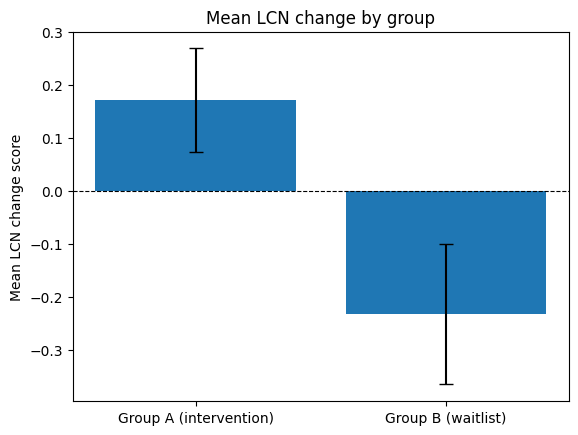

In [22]:
# calculate the standard error of LCN_change for each group - used for error bars
error = LCN_dataframe.groupby('Group')['LCN_change'].sem() # standard error of the mean (SEM)

fig, ax = plt.subplots()
ax.bar(['Group A (intervention)', 'Group B (waitlist)'], means, yerr=error, capsize=5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Mean LCN change score')
ax.set_title('Mean LCN change by group')
plt.show()

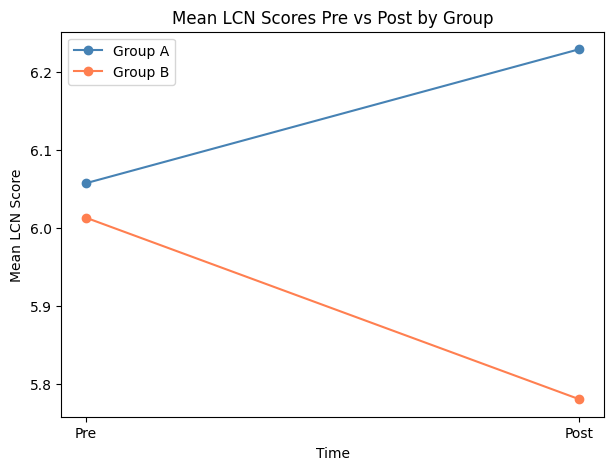

In [23]:
# now calculating the mean pre and post LCN scores for each group
group_means = LCN_dataframe.groupby('Group')[['Pre_LCN_score', 'Post_LCN_score']].mean()

fig, ax = plt.subplots(figsize=(7, 5))
# plotting a line from pre to post score for Group A
ax.plot(['Pre', 'Post'], group_means.loc['A'], marker='o', label='Group A', color='steelblue') #go to the row labelled A in group_means and give me all the values in it.

# plot a line from pre to post score for Group B
ax.plot(['Pre', 'Post'], group_means.loc['B'], marker='o', label='Group B', color='coral')# same here

ax.set_ylabel('Mean LCN Score')
ax.set_xlabel('Time')
ax.set_title('Mean LCN Scores Pre vs Post by Group')
ax.legend()
plt.show()

### What does this mean?

Group A showed greater increases in nature connectedness (mean=+0.17) compared to Group B (mean=-0.23) confirming the direction of H1. This means we can accept H1: Participants who completed the urban bird connection toolkit showed significantly greater increases in nature connectedness (LCN) compared to waitlist control participants over the 10-day period. 

However -  we can see an obvious diverging pattern. In a waitlist control you'd likely expect group B's line to be straight rather than decreasing. Group A increasing whilst Group B declines could reflect several things. For example, waiting passively whilst knowing a study is ongoing may have had a subtly deflating effect on Group B's relationship with nature. Or it may simply reflect natural fluctuation in LCN scores over time in the absence of any intervention. We'll revisit this in the write up.

For now, we know that the difference between group A and B LCN_changes is significant and we know the direction - but we don't know the size. We'll use Cohen's d to calculate effect size...

## Effect Size Calculations

### Bessels correction

To calculate Cohen's d we first need the pooled standard deviation which is a combined measure of spread across both groups. To get an accurate estimate of the true population variance from our small sample, we use Bessel's correction. Bessels’ correction refers to the “n-1” found in several formulas, including the sample variance and sample standard deviation formulas. This correction is made to correct for the fact that these sample statistics tend to underestimate the actual parameters found in the population. 

source: https://www.statisticshowto.com/bessels-correction/

Bessel's correction (ddof=1) is applied as the study aims to draw tentative inferences beyond the immediate sample as recommended by Warne (2017). source: https://books.google.co.uk/books?id=-c9CDwAAQBAJ&redir_esc=y

However, given the small and non-representative sample (n=59), findings should be interpreted cautiously and not generalised broadly.

In [24]:
# Storing the size of group A and B as variables rather than hard coding - in case anyone else withdraws at a later point before submission
n_A = len(LCN_dataframe[LCN_dataframe['Group'] == 'A'])
n_B = len(LCN_dataframe[LCN_dataframe['Group'] == 'B'])

In [25]:
# First we calculate the variance (spread) of LCN_change scores for each group separately.
# ddof=1 applies Bessel's correction — dividing by n-1 instead of n.
var_a = LCN_dataframe[LCN_dataframe['Group'] == 'A']['LCN_change'].var(ddof=1)
var_b = LCN_dataframe[LCN_dataframe['Group'] == 'B']['LCN_change'].var(ddof=1)

In [26]:
# Now we combine both variances into one pooled standard deviation.
# We can't just average the two variances, we need to weight each one by its sample size (degrees of freedom = n-1) so that the larger group has more influence on the combined estimate.
# Step 1: weight Group A's variance by its degrees of freedom (n1-1)
# Step 2: weight Group B's variance by its degrees of freedom (n2-1)
# Step 3: add them together and divide by total degrees of freedom (n1+n2-2)
# Step 4: take the square root to get back to standard deviation (not variance)
pooled_std = np.sqrt(((n_A-1)*var_a + (n_B-1)*var_b) / (n_A+n_B-2))
pooled_std

np.float64(0.6410638744296192)

### Cohen's d

In [27]:
# we already have the pooled means saved as 'means' so we just need to split
mean_a = means['A']
mean_b = means['B']
# Cohen's d
# dividing the difference between group means by the pooled standard deviation
cohens_d = (mean_a - mean_b) / pooled_std
cohens_d

np.float64(0.6297135933667716)

In [28]:
# Interpretation based on Cohen's (1988) benchmarks
if abs(cohens_d) < 0.2:
    effect_size = "too small"
elif abs(cohens_d) < 0.5:
    effect_size = "small"
elif abs(cohens_d) < 0.8:
    effect_size = "medium"
else:
    effect_size = "large"

effect_size

'medium'

### What does this mean?
> Cohen's d = 0.63...

> Effect size = medium

A Cohen's d of 0.63 means that the difference between Group A and Group B's LCN change scores is 0.63 standard  deviations apart. Using Cohen's (1988) benchmarks (small = 0.2, medium = 0.5, large = 0.8), this is a medium-to-large effect meaning that the intervention produced not just a statistically significant difference but a meaningfully sized one too. It is worth noting that our power analysis was conducted assuming a medium effect size (d = 0.5), so this result is consistent with and slightly exceeds our original assumptions. However, is Cohen's d the most appropriete test here?

"The most appropriate effect size measure for Mann-Whitney U analysis is the rank-biserial correlation coefficient (r). It provides an estimate of the strength and direction of the relationship between the independent groups and the outcome variable. The rank-biserial correlation coefficient ranges from -1 to 1, where -1 indicates a perfect negative relationship, 0 signifies no relationship, and 1 denotes a perfect positive relationship. It is calculated based on the U statistic from the Mann-Whitney U test and specific formulas depending on the test version and sample sizes. Other effect size measures like odds ratio or Cohen's d can also be utilized, but the rank-biserial correlation coefficient is commonly used and suitable for this type of analysis. For relevant insights, you could check out section 5.12 in the following book: Berry, K. J., Johnston, J. E., & Mielke, P. W. (2018). The measurement of association: A permutation statistical approach. Springer. https://doi.org/10.1007/978-3-319-98926-6"


Alotumi, Mohialdeen. (2023). Re: What is the most appropriate effect size type for mann whitney u analysis?. Retrieved from: https://www.researchgate.net/post/What_is_the_most_appropriate_effect_size_type_for_mann_whitney_u_analysis/647e6a564da51ad8f30390ef/citation/download. 

We will therefore also calculate rank-biserial correlation coefficient to report alongside Cohen's d - since Cohen's d is more widely used and compared.

### Rank-biserial correlation coefficient

https://www.statisticshowto.com/rank-biserial-correlation/

In [29]:
# r = 1 - (2U / n1*n2)
rank_biserial = abs(1 - (2 * u_mann) / (n_A * n_B))
rank_biserial

np.float64(0.33179723502304137)

In [30]:
if abs(rank_biserial) < 0.1:
    effect_size_r = "too small"
elif abs(rank_biserial) < 0.3:
    effect_size_r = "small"
elif abs(rank_biserial) < 0.5:
    effect_size_r = "medium"
else:
    effect_size_r = "large"

print("Effect size:", effect_size_r)

Effect size: medium


source for rank-biserial thresholds: https://dl.acm.org/doi/full/10.1145/3772318.3790282

### What does this mean?
> Rank-biserial r = 0.332
> Effect size = medium

Rank-biserial confirms that our finding is a medium effect size (r = 0.332), consistent with Cohen's d = 0.63. Using Cohen's (1988) conventions (small ≥ 0.1, medium ≥ 0.3, large ≥ 0.5), both effect size measures converge on a medium effect,  strengthening confidence in the result.

### The Probability of Superiority

"The most appropriate effect size type for Mann-Whitney U analysis, also known as the Wilcoxon rank-sum test, is typically the probability of superiority (PS) or the probability of one randomly chosen observation from one group being greater than a randomly chosen observation from the other group.[...] The probability of superiority (PS) is calculated as the proportion of pairs of observations where an observation from one group is greater than an observation from the other group. It provides a measure of the probability that a randomly selected observation from one group will have a higher value than a randomly selected observation from the other group.
The advantage of using the probability of superiority as the effect size measure is that it is intuitive and easy to interpret. It directly reflects the probability of one group being superior to the other. However, it's important to note that effect size interpretation can vary depending on the specific context and field of study.
When reporting the results of the Mann-Whitney U analysis, it is recommended to include the effect size measure, such as the probability of superiority, along with the statistical significance to provide a comprehensive understanding of the findings"

Yadav, Pankaj Kumar. (2023). Re: What is the most appropriate effect size type for mann whitney u analysis?. Retrieved from: https://www.researchgate.net/post/What_is_the_most_appropriate_effect_size_type_for_mann_whitney_u_analysis/647ed60074c20804930f4afb/citation/download. 

I am also reporting the probability of superiority here for the product (the final toolkit booklet) where the data will need to be understood without having specialist knowledge of effect size calculations.

In [31]:
PS = u_mann / (n_A * n_B) #The Mann-Whitney U statistic (stat) counts how many times a Group A participant's LCN change score 
# beat a Group B participant's LCN change score across all possible pairings. So it's comparing every single Group A person
# against every single Group B person one by one.
# Dividing by n1 * n2 (28 × 31 = 868, the total number of possible pairings) converts that raw count into a proportion so you
# get the probability that a randomly picked Group A participant improved more than a randomly picked Group B participant.
print(PS)
round(PS*100, 1)

0.6658986175115207


np.float64(66.6)

> Probability of Superiority = 0.666
> 
> In plain English: Group A participants had a 66.6% probability of showing greater LCN increase than Group B

### Sensitivity Checks

The following sensitivity analyses were conducted post-hoc to assess the robustness of the primary finding. First, the analysis was re-run with the extreme Group B outlier (-3.2) removed. Second, the analysis was restricted to participants who  completed 5 or more tasks, on the basis that very low engagement may not constitute a meaningful dose of the intervention. Third, a Wilcoxon signed-rank test was conducted to account for the matched pairs design.

**Removing Outlier**

In [32]:
# removing extreme outlier (LCN_change = -3.2)
LCN_outlier = LCN_dataframe[LCN_dataframe['LCN_change'] != -3.2].copy()

In [33]:
#re-running the mann whitney test again
u_mann_removed, p_mann_removed = mannwhitneyu(
    LCN_outlier[LCN_outlier['Group'] == 'A']['LCN_change'],
    LCN_outlier[LCN_outlier['Group'] == 'B']['LCN_change'],
    alternative='two-sided'
)
print("Outlier removed n =", len(LCN_outlier), "U =", u_mann_removed, "p_=", p_mann_removed)

Outlier removed n = 58 U = 550.0 p_= 0.042082168106618086


To check whether this single participant was driving the main result, the Mann-Whitney test was re-run with this participant removed (n=58). The result remained significant (U=550, p=.042), suggesting the main finding is not dependent on this one extreme value. The toolkit still produced significantly greater increases in nature connectedness than the waitlist control even without this participant.

**Engaged participants only**

In [34]:
# filtering to only participants who completed 5 or more tasks
LCN_engaged = LCN_dataframe[LCN_dataframe['Task_engagement'] >= 5].copy()

In [35]:
# re-run Mann-Whitney on engaged participants only
u_engaged, p_engaged = mannwhitneyu(
    LCN_engaged[LCN_engaged['Group'] == 'A']['LCN_change'],
    LCN_engaged[LCN_engaged['Group'] == 'B']['LCN_change'],
    alternative='two-sided'
)

print("5+ tasks only, n =", len(LCN_engaged), "U =", u_engaged, "p =", p_engaged)

5+ tasks only, n = 37 U = 193.5 p = 0.38470478093708405


When restricting the analysis to participants who completed 5 or more tasks (n=37), the result was no longer significant (U=193.5, p=.385). This suggests that the main finding may be partly driven by disengagement in the waitlist condition. This suggests that the significant main finding may be partly explained by the waitlist group's LCN scores declining over the 10 day waiting period, rather than purely reflecting a positive effect of the toolkit on Group A.

**Wilcoxon rank**

In [36]:
# The Wilcoxon test needs the data in a different format - each matched pair on one row
# So we need to split the data into two separate tables, one for Group A and one for Group B

# grab Group A's matched_pair number and LCN_change, rename LCN_change to LCN_change_A so we know which group it belongs to
group_a = LCN_dataframe[LCN_dataframe['Group'] == 'A'][['matched_pair', 'LCN_change']].rename(columns={'LCN_change': 'LCN_change_A'})

# same for Group B
group_b = LCN_dataframe[LCN_dataframe['Group'] == 'B'][['matched_pair', 'LCN_change']].rename(columns={'LCN_change': 'LCN_change_B'})

In [37]:
# joining the two tables together using matched_pair as the common key
# any pairs where one person dropped out will be excluded automatically
paired = group_a.merge(group_b, on='matched_pair')

print("Pairs available:", len(paired))

Pairs available: 24


In [38]:
# run the wilcoxon signed-rank test on the 24 complete matched pairs
# this compares each pair directly rather than treating the groups as independent
w_wilcoxon, p_wilcoxon = wilcoxon(paired['LCN_change_A'], paired['LCN_change_B'])

# print the results
print("Wilcoxon signed-rank test")
print("n pairs =", len(paired))
print("W =", w_wilcoxon)
print("p =", p_wilcoxon)

Wilcoxon signed-rank test
n pairs = 24
W = 44.0
p = 0.022461720621119948


Unlike Mann-Whitney which treats the two groups as independent, the Wilcoxon signed-rank test directly compares each matched pair the design used in this study. Of the original 35 pairs, 24 complete pairs remained after dropouts. The result was still significant (W=44, p=.022)! This is consistent with the main Mann-Whitney result (U=578, p=.028). This confirms that the finding holds when the matched pairs design is fully exploited, and that the two tests converge on the same conclusion even when there are less participants accounted for. 

### H1 Accepted
Participants who completed the urban bird connection toolkit showed significantly greater increases in nature connectedness (LCN) compared to waitlist control participants over the 10-day period (U = 578.000, p = .028, r = .332, d = 0.63). With some caveats as demonstrated by the sensitivity checks! 

Let's move on to H2...

# H2: Perceived Time Poverty Scale
> **H2:** Perceived time poverty does not predict outcomes in this sample:
> 
> &nbsp;&nbsp;&nbsp;&nbsp;**H2.1** PTPS scores do not predict task engagement across the intervention period.

In [39]:
print(all_data_ever.columns.tolist())

['ID', 'Pre_LCN_1', 'Post_LCN_1', 'Pre_LCN_2', 'Post_LCN_2', 'Pre_LCN_3', 'Post_LCN_3', 'Pre_LCN_4', 'Post_LCN_4', 'Pre_LCN_5', 'Post_LCN_5', 'PTPS_1', 'PTPS_2', 'PTPS_3', 'PTPS_4', 'PTPS_5', 'PTPS_6', 'Task_engagement', 'Pre_LCN_score', 'Post_LCN_score', 'PTPS_Score', 'matched_pair', 'Group', 'Status of participation ', 'LCN_change']


In [40]:
#These are the columns Im keeping in a new dataframe for PTPS calculations.
PTPS_dataframe = all_data_ever[['ID', 'PTPS_Score', 'Task_engagement', 'Group', 'LCN_change', 'matched_pair']]
PTPS_dataframe.head()

,ID,PTPS_Score,Task_engagement,Group,LCN_change,matched_pair
0,P26,2.67,10,A,0.4,0
1,P6,4.33,1,A,0.0,1
3,P7,5.67,10,A,1.2,3
4,P2,5.33,2,A,0.0,4
5,P21,4.50,5,A,1.2,5


In [41]:
# Task_engagement is the outcome variable, PTPS_Score is the predictor
# outcome variable ~ predictor
# .fit() runs the regression and stores the results in H21
H21 = smf.ols('Task_engagement ~ PTPS_Score', data=PTPS_dataframe).fit()
print(H21.summary())

                            OLS Regression Results                            
Dep. Variable:        Task_engagement   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                   0.03910
Date:                Tue, 09 Jun 2026   Prob (F-statistic):              0.844
Time:                        18:48:36   Log-Likelihood:                -152.80
No. Observations:                  59   AIC:                             309.6
Df Residuals:                      57   BIC:                             313.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.9474      1.758      3.383      0.0

### What does this mean?

- R-squared = 0.001: PTPS_Score explains only 0.1% of the variance in task engagement. This is basically zero. Time poverty has almost no explanatory power over how many tasks participants completed.
  
- Adjusted R-squared = -0.017: The model actually performs worse than just predicting the mean. A negative adjusted R² confirms the model is not useful (No model would do better because the relationship simply isn't there in the data).

- F-statistic = 0.039, p = .844: Tests whether the overall model is better than just predicting the mean. An F of 0.039 (much less than 1) means the model explains less variance than random chance would.
  
- PTPS_Score coefficient = -0.072, p = .844 — for every 1 point increase in PTPS, task engagement decreases by 0.07 tasks. But p=.844 means this is nowhere near significant 

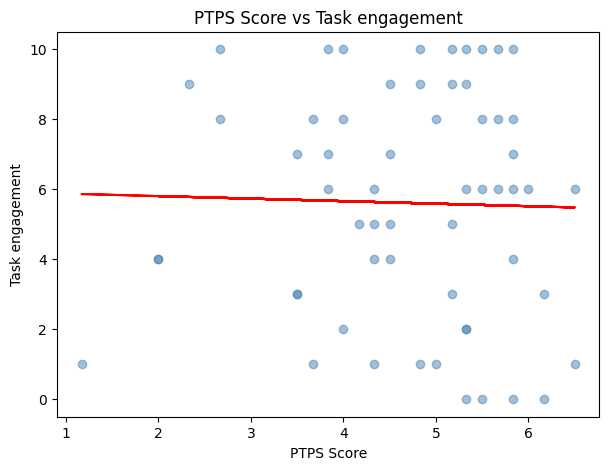

In [42]:
# Creating a scatter plot of PTPS scores vs task engagement
fig, ax = plt.subplots(figsize=(7, 5))

# plotting each participant as a dot
ax.scatter(PTPS_dataframe['PTPS_Score'], PTPS_dataframe['Task_engagement'], alpha=0.5, color='steelblue')

# calculating the slope and intercept of the regression line
m, b = np.polyfit(PTPS_dataframe['PTPS_Score'], PTPS_dataframe['Task_engagement'], 1)
# np.polyfit fits a polynomial to the data. The 1 at the end tells it to fit a straight line (degree 1 = linear).
# It returns two values — the slope (m) and the intercept (b)  which are then used to draw the line with y = mx + b
# now drawing the regression line on top of the scatter plot
ax.plot(PTPS_dataframe['PTPS_Score'], m * PTPS_dataframe['PTPS_Score'] + b, color='red', linewidth=1.5)

ax.set_xlabel('PTPS Score')
ax.set_ylabel('Task engagement')
ax.set_title('PTPS Score vs Task engagement')
plt.show()

The scatter plot visualises the OLS regression result. The red line is nearly flat, showing no meaningful relationship between PTPS score and task engagement. Participants completed a similar number of tasks regardless of how time-poor they felt.

## H2.1 Accepted
PTPS scores did not significantly predict task engagement across the intervention period. Time poverty does not appear to predict how many tasks participants completed.

Let's move on to H2.2...

> **H2.2**: PTPS scores do not predict changes in LCN scores following the intervention

In [43]:
# filter to Group A only since we only want people who actually did the intervention
group_a_only = PTPS_dataframe[PTPS_dataframe['Group'] == 'A'].copy()

# run another OLS regression to test whether PTPS predicts LCN change in intervention participants
H22 = smf.ols('LCN_change ~ PTPS_Score', data=group_a_only).fit()
print(H22.summary())

                            OLS Regression Results                            
Dep. Variable:             LCN_change   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                 -0.019
Method:                 Least Squares   F-statistic:                    0.4989
Date:                Tue, 09 Jun 2026   Prob (F-statistic):              0.486
Time:                        18:48:36   Log-Likelihood:                -20.406
No. Observations:                  28   AIC:                             44.81
Df Residuals:                      26   BIC:                             47.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0840      0.375     -0.224      0.8

### What does this mean?

### H2.2 Results

- R-squared = 0.019: PTPS explains only 1.9% of the variance in LCN change in intervention participants.
  
- Adjusted R-squared = -0.019: the model performs worse than just predicting the mean.
  
- PTPS_Score coefficient = 0.056, p = .486: PTPS does not significantly predict LCN change.

In laymans, how time-poor someone felt made no difference to how much their nature connectedness changed after completing the toolkit.

## H2.2 Accepted
PTPS scores did not significantly predict LCN change in intervention participants and therefore we can conclude that both H2 hypotheses combined, that time poverty does not appear to influence how much participants benefited from the bird connection toolkit.

# Conclusion

The primary finding of this study is a significant and meaningful effect of the 
urban bird connection toolkit on nature connectedness (LCN), with participants 
in the intervention group showing greater increases than waitlist control 
participants over the 10-day period. 

This is a medium effect size, consistent with and slightly exceeding the medium 
effect assumed in the power analysis. However, sensitivity analysis restricting 
to participants who completed 5 or more tasks did not reach significance, suggesting the main result may be partly explained by passive decline in 
LCN scores in the waitlist condition rather than solely reflecting a positive 
intervention effect. The Wilcoxon signed-rank test on 24 complete matched pairs 
confirmed the main finding.

Time poverty (PTPS) did not predict task engagement nor predict LCN change in intervention participants. The finding that time poverty did not reduce task engagement 
suggests the toolkit was accessible regardless of how time-poor participants felt. This is a  meaningful result and an important barrier to test in future interventions targeting busy urban adults.

Taken together, these findings provide support for the effectiveness of the bird 
connection toolkit as a nature connectedness intervention, whilst highlighting the 
need for further research to disentangle how an active control might be designed for compounding interventions of this type to avoid any inflation affects caused by a waitlist control.

## Beyond Hypotheses

Now that Ive answered the hypotheses, we're going to have a look at the individual LCN dimensions to map each one on to 5 pathways. Now, we know that the LCN was created predominantly to understand emotions and care for nature - rather than changes in meaning, for example. However, some of these dimensions may help us understand why LCN increased overall and which dimensions increased the most as a result of the study. This is exploratory and is not hypothesis led. This will serve integration.

In [44]:
# LCN dimension-level analysis using Group A only
# Each LCN item measures a different dimension of nature connectedness
# We want to see which dimensions changed the most after the intervention

# defining which columns belong to which dimension
lcn_dimensions = {
    'LCN1 (Love)':                ('Pre_LCN_1', 'Post_LCN_1'),
    'LCN2 (Protection)':          ('Pre_LCN_2', 'Post_LCN_2'),
    'LCN3 (Awe & wonder)':        ('Pre_LCN_3', 'Post_LCN_3'),
    'LCN4 (Care)':                ('Pre_LCN_4', 'Post_LCN_4'),
    'LCN5 (Emotional closeness)': ('Pre_LCN_5', 'Post_LCN_5'),
}


# doing a calculation: for each dimension, calculate the average score before and after
# then subtract pre from post to get the mean change
for dimension_name, (pre_column, post_column) in lcn_dimensions.items(): # loop through each dimension one at a time
    pre_mean  = all_data_ever[all_data_ever['Group'] == 'A'][pre_column].mean()# filter to Group A then get average pre score
    post_mean = all_data_ever[all_data_ever['Group'] == 'A'][post_column].mean()# filter to Group A then get average post score
    change    = post_mean - pre_mean  # subtract pre from post to get mean change
    print(f'{dimension_name}: pre={pre_mean:.3f}  post={post_mean:.3f}  change={change:+.3f}') # print result, + forces sign to always show# print result, + forces sign to always show

LCN1 (Love): pre=6.107  post=6.321  change=+0.214
LCN2 (Protection): pre=6.286  post=6.357  change=+0.071
LCN3 (Awe & wonder): pre=6.179  post=6.393  change=+0.214
LCN4 (Care): pre=6.107  post=6.214  change=+0.107
LCN5 (Emotional closeness): pre=5.607  post=5.857  change=+0.250
